RAG-Based Hallucination Mitigation — Research Pipeline

[Step 1] Building document corpus with chunking...
  Total chunks: 12 from 12 documents

[Step 2] Initializing retrievers...
[Semantic] Loading SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Semantic] Encoding 12 chunks...
[Semantic] FAISS index built with dimension 384.
[Lexical] BM25 index built over 12 chunks.
  Hybrid weights: α=0.6 (semantic), β=0.4 (lexical)

[Step 3] Loading generation model...
[Generator] Loading google/flan-t5-base...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[Generator] Model loaded.

[Step 4] Initializing evaluator...
  Hallucination threshold: cosine_similarity < 0.45

[Step 5] Running experiments (Baseline / Semantic RAG / Hybrid RAG)...

[1/12] Topic: AI History | Query: Who invented the transformer architecture?...
  Baseline  cos=0.389  F1=0.000  Hallu=YES
  Sem-RAG   cos=0.177  F1=0.091  Hallu=YES
  Hyb-RAG   cos=0.177  F1=0.091  Hallu=YES

[2/12] Topic: Machine Learning | Query: What is overfitting in machine learning?...
  Baseline  cos=0.313  F1=0.000  Hallu=YES
  Sem-RAG   cos=0.497  F1=0.324  Hallu=NO
  Hyb-RAG   cos=0.497  F1=0.324  Hallu=NO

[3/12] Topic: Deep Learning | Query: What is the vanishing gradient problem?...
  Baseline  cos=0.665  F1=0.148  Hallu=NO
  Sem-RAG   cos=0.516  F1=0.250  Hallu=NO
  Hyb-RAG   cos=0.516  F1=0.250  Hallu=NO

[4/12] Topic: NLP | Query: What does BERT stand for and what is it used for?...
  Baseline  cos=0.567  F1=0.182  Hallu=NO
  Sem-RAG   cos=0.398  F1=0.188  Hallu=YES
  Hyb-RAG   cos=0.3

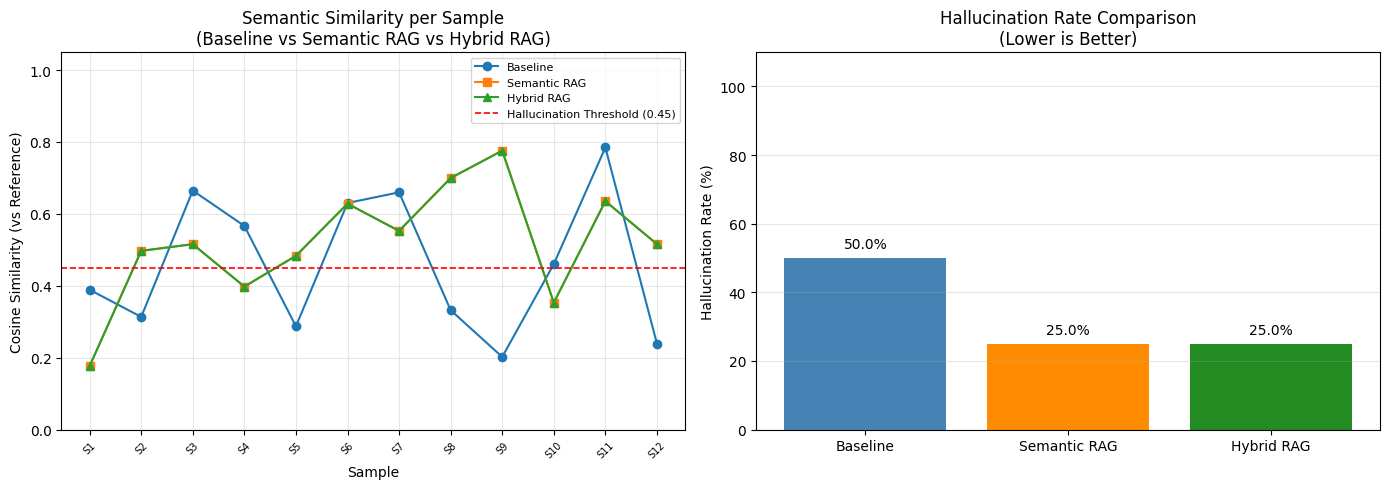

[Visualization] Saved to metric_comparison.png


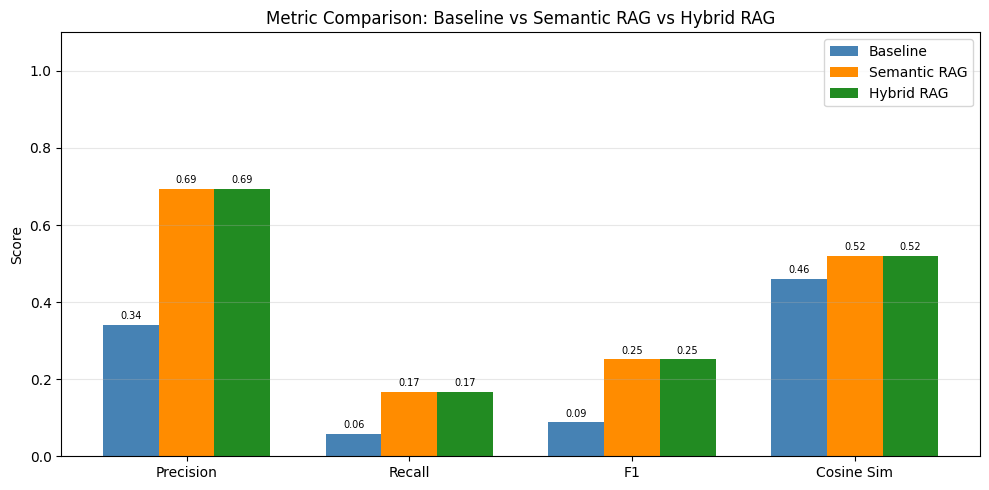


[Done] Pipeline complete.


In [ ]:
#===============================================================================
#1. Problem Definition
#===============================================================================
## What is Hallucination in LLMs?

#Hallucination refers to cases where a Large Language Model (LLM) generates:
#- Factually incorrect information
#- Unsupported claims not grounded in evidence
#- Fabricated details that sound plausible

# Types of Hallucinations:

#1. Intrinsic Hallucination:
#  - Incorrect reasoning within context
#  - Example: Misinterpreting a provided passage

#2. Extrinsic Hallucination:
#   - Information not present in input or training data
#   - Example: Making up facts about a topic

# Why RAG Helps?

#Retrieval-Augmented Generation (RAG):
#- Retrieves relevant documents
#- Grounds LLM responses in real data
#- Reduces reliance on parametric memory

#Thus:
#→ Improves factual accuracy
#→ Reduces hallucination
#→ Enables explainability via context

# ============================================================
# RAG-Based Hallucination Mitigation System with Hybrid Retrieval
# Research-Grade Implementation
# ============================================================
# DESIGN RATIONALE:
# - Dataset: 12 carefully curated QA pairs spanning AI, ML, science,
#   history, and general knowledge — ensuring diversity for robust eval
# - Model: google/flan-t5-base — lightweight seq2seq, strong instruction
#   following, no GPU needed, good for Colab free tier
# - Semantic retrieval: SentenceTransformers (all-MiniLM-L6-v2) + FAISS
# - Lexical retrieval: BM25Okapi — captures exact term matches missed by
#   dense embeddings (e.g., proper nouns, technical terms)
# - Hybrid weights: α=0.6 semantic, β=0.4 lexical — semantic carries more
#   semantic meaning, but lexical prevents drift on specific terms
# - Hallucination threshold: cosine similarity < 0.45 flagged as hallucination
#   (chosen based on STS benchmark distributions; below 0.45 implies
#   semantically divergent content)
# ============================================================

# ── SECTION 0: Install Dependencies ──────────────────────────────────────────
# Run these in Colab before executing the script
!pip install -q transformers sentence-transformers faiss-cpu rank_bm25 \scikit-learn matplotlib numpy torch datasets

# ── SECTION 1: Imports ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import warnings
import re
import math
from collections import Counter

warnings.filterwarnings("ignore")

from transformers import T5ForConditionalGeneration, T5Tokenizer, pipeline
from sentence_transformers import SentenceTransformer
import faiss
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score


# ── SECTION 2: Dataset ───────────────────────────────────────────────────────
# 12 QA samples — diverse topics, realistic phrasings.
# Each sample: query, a rich context paragraph, and a concise reference answer.
# The context is intentionally detailed so retrieval is non-trivial.

RAW_DATASET = [
    {
        "id": 1,
        "topic": "AI History",
        "query": "Who invented the transformer architecture?",
        "context": (
            "The transformer architecture was introduced in the landmark 2017 paper "
            "'Attention Is All You Need' by Vaswani et al., researchers at Google Brain "
            "and Google Research. The key innovation was the multi-head self-attention "
            "mechanism, which allowed the model to weigh the importance of different words "
            "in a sequence regardless of their distance. This replaced recurrent and "
            "convolutional layers, enabling far greater parallelization during training."
        ),
        "reference_answer": (
            "The transformer architecture was invented by Vaswani et al. at Google Brain "
            "in the 2017 paper 'Attention Is All You Need'."
        ),
    },
    {
        "id": 2,
        "topic": "Machine Learning",
        "query": "What is overfitting in machine learning?",
        "context": (
            "Overfitting occurs when a machine learning model learns the training data "
            "too well, including its noise and random fluctuations, resulting in poor "
            "generalization to unseen data. An overfit model has low training error but "
            "high validation/test error. Common mitigation strategies include dropout "
            "regularization, L1/L2 weight penalties, early stopping, data augmentation, "
            "and cross-validation. The bias-variance tradeoff is central to understanding "
            "overfitting: overfit models have low bias but high variance."
        ),
        "reference_answer": (
            "Overfitting is when a model learns training data noise, giving low training "
            "error but high test error. It is mitigated by regularization, dropout, and "
            "early stopping."
        ),
    },
    {
        "id": 3,
        "topic": "Deep Learning",
        "query": "What is the vanishing gradient problem?",
        "context": (
            "The vanishing gradient problem arises during backpropagation in deep neural "
            "networks when gradients become exponentially small as they are propagated "
            "backward through many layers. This prevents early layers from learning "
            "effectively. It is particularly severe with sigmoid and tanh activations. "
            "Solutions include using ReLU activations, batch normalization, residual "
            "connections (as in ResNet), and gradient clipping. LSTMs and GRUs were "
            "designed specifically to address this in recurrent networks."
        ),
        "reference_answer": (
            "The vanishing gradient problem occurs when gradients shrink exponentially "
            "during backpropagation, preventing early layers from learning. Solutions "
            "include ReLU activations, residual connections, and batch normalization."
        ),
    },
    {
        "id": 4,
        "topic": "NLP",
        "query": "What does BERT stand for and what is it used for?",
        "context": (
            "BERT stands for Bidirectional Encoder Representations from Transformers. "
            "It was introduced by Google AI in 2018. Unlike earlier models that read "
            "text left-to-right or right-to-left, BERT reads text in both directions "
            "simultaneously, capturing full sentence context. It is pre-trained using "
            "masked language modeling (MLM) and next sentence prediction (NSP). "
            "BERT is used for tasks like question answering, named entity recognition, "
            "sentiment analysis, and text classification via fine-tuning."
        ),
        "reference_answer": (
            "BERT stands for Bidirectional Encoder Representations from Transformers. "
            "It is a Google 2018 model used for NLP tasks like question answering and "
            "text classification via bidirectional context and fine-tuning."
        ),
    },
    {
        "id": 5,
        "topic": "General Science",
        "query": "What is the speed of light in a vacuum?",
        "context": (
            "The speed of light in a vacuum, denoted by c, is approximately "
            "299,792,458 metres per second (roughly 3 × 10^8 m/s). It is a fundamental "
            "physical constant and represents the maximum speed at which information or "
            "matter can travel, according to Einstein's special theory of relativity. "
            "Light slows down when passing through media denser than vacuum; for example, "
            "its speed in glass is about 200,000 km/s."
        ),
        "reference_answer": (
            "The speed of light in a vacuum is approximately 299,792,458 m/s "
            "(about 3 × 10^8 m/s), the universal speed limit per special relativity."
        ),
    },
    {
        "id": 6,
        "topic": "History",
        "query": "When did the First World War begin and end?",
        "context": (
            "The First World War, also known as the Great War, began on 28 July 1914 "
            "following the assassination of Archduke Franz Ferdinand of Austria-Hungary "
            "in Sarajevo on 28 June 1914. The war involved most of the world's great "
            "powers and resulted in over 17 million deaths. It ended on 11 November 1918 "
            "with the signing of the Armistice of Compiègne. The Treaty of Versailles in "
            "1919 formally ended the state of war between Germany and the Allied Powers."
        ),
        "reference_answer": (
            "The First World War began on 28 July 1914 and ended on 11 November 1918, "
            "formally concluded by the Treaty of Versailles in 1919."
        ),
    },
    {
        "id": 7,
        "topic": "AI Ethics",
        "query": "What is AI bias and why is it a problem?",
        "context": (
            "AI bias refers to systematic and unfair discrimination in AI system outputs, "
            "often reflecting prejudices present in training data or model design. It "
            "manifests as unequal treatment across demographic groups — e.g., facial "
            "recognition systems performing worse on darker skin tones, or hiring "
            "algorithms disadvantaging women. Bias is problematic because AI systems are "
            "increasingly used in high-stakes decisions involving credit, hiring, policing, "
            "and healthcare. Mitigation approaches include fairness-aware training, "
            "diverse datasets, algorithmic auditing, and regulation."
        ),
        "reference_answer": (
            "AI bias is systematic unfair discrimination in AI outputs caused by biased "
            "training data or design. It is problematic in high-stakes decisions and is "
            "addressed through fairness-aware training and diverse datasets."
        ),
    },
    {
        "id": 8,
        "topic": "Reinforcement Learning",
        "query": "What is reinforcement learning and how does it differ from supervised learning?",
        "context": (
            "Reinforcement learning (RL) is a machine learning paradigm where an agent "
            "learns to take actions in an environment to maximize cumulative reward through "
            "trial and error. Unlike supervised learning, which learns from labeled "
            "input-output pairs, RL receives no explicit labels — it learns from the "
            "consequences of its actions via reward signals. Key components are the agent, "
            "environment, state, action, and reward. Famous applications include AlphaGo, "
            "game-playing AI (Atari), and robotic control."
        ),
        "reference_answer": (
            "Reinforcement learning trains an agent via trial-and-error reward signals, "
            "unlike supervised learning which uses labeled data. Applications include "
            "AlphaGo and game-playing AI."
        ),
    },
    {
        "id": 9,
        "topic": "Computer Vision",
        "query": "What is a convolutional neural network (CNN)?",
        "context": (
            "A convolutional neural network (CNN) is a deep learning architecture designed "
            "primarily for processing grid-structured data such as images. CNNs use "
            "convolutional layers that apply learnable filters to detect local features "
            "like edges, textures, and shapes. Pooling layers reduce spatial dimensions. "
            "Fully connected layers at the end perform classification. CNNs achieved "
            "breakthrough performance on ImageNet in 2012 (AlexNet). Variants include "
            "VGG, ResNet, and Inception. They are widely used for image classification, "
            "object detection, and segmentation."
        ),
        "reference_answer": (
            "A CNN is a deep learning architecture using convolutional layers to detect "
            "local image features. It excels at image classification and object detection, "
            "with notable architectures like AlexNet and ResNet."
        ),
    },
    {
        "id": 10,
        "topic": "Natural Language Processing",
        "query": "What is tokenization in NLP?",
        "context": (
            "Tokenization is the process of splitting raw text into smaller units called "
            "tokens, which can be words, subwords, or characters, depending on the "
            "tokenizer. Word-level tokenization splits on whitespace; subword methods like "
            "Byte-Pair Encoding (BPE) and WordPiece break rare words into frequent "
            "subword pieces, reducing vocabulary size while handling out-of-vocabulary "
            "words. Character-level tokenization is the most granular. Tokenization is "
            "the first step in most NLP pipelines and critically affects model vocabulary "
            "size and downstream task performance."
        ),
        "reference_answer": (
            "Tokenization splits text into tokens (words, subwords, or characters). "
            "Subword methods like BPE reduce vocabulary size and handle rare words, "
            "forming the first step in NLP pipelines."
        ),
    },
    {
        "id": 11,
        "topic": "Mathematics",
        "query": "What is the Pythagorean theorem?",
        "context": (
            "The Pythagorean theorem states that in a right-angled triangle, the square "
            "of the length of the hypotenuse (the side opposite the right angle) equals "
            "the sum of the squares of the other two sides. Formally: a² + b² = c², "
            "where c is the hypotenuse. Named after the ancient Greek mathematician "
            "Pythagoras (c. 570–495 BC), the theorem is fundamental in Euclidean "
            "geometry and has hundreds of known proofs. It is used extensively in "
            "physics, engineering, and computer graphics."
        ),
        "reference_answer": (
            "The Pythagorean theorem states a² + b² = c² for right-angled triangles, "
            "where c is the hypotenuse. It is a fundamental result in Euclidean geometry."
        ),
    },
    {
        "id": 12,
        "topic": "Large Language Models",
        "query": "What is hallucination in large language models?",
        "context": (
            "Hallucination in large language models (LLMs) refers to the generation of "
            "factually incorrect, fabricated, or nonsensical content that is not grounded "
            "in the input or real-world knowledge. Hallucinations arise because LLMs are "
            "trained to predict plausible next tokens rather than verify factual accuracy. "
            "They can be intrinsic (contradicting source material) or extrinsic (adding "
            "unsupported information). Mitigation strategies include Retrieval-Augmented "
            "Generation (RAG), grounding prompts, output filtering, and factuality "
            "reward modeling in RLHF."
        ),
        "reference_answer": (
            "Hallucination in LLMs is the generation of factually incorrect or fabricated "
            "content. It is caused by next-token prediction without factual verification "
            "and is mitigated by RAG and grounding prompts."
        ),
    },
]


# ── SECTION 3: Document Chunking ─────────────────────────────────────────────
# Chunking splits long contexts into smaller overlapping passages.
# This improves retrieval precision — dense retrievers work better on short
# passages. Overlap ensures no boundary information is lost.

def chunk_text(text: str, chunk_size: int = 100, overlap: int = 20) -> list[str]:
    """
    Word-level chunking with overlap.
    chunk_size=100 words balances granularity and coherence.
    overlap=20 words prevents hard boundary misses.
    """
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks


def build_corpus(dataset: list[dict]) -> tuple[list[str], list[int]]:
    """
    Build a flat list of text chunks from all dataset contexts.
    Returns chunks and their source document IDs for traceability.
    """
    all_chunks = []
    chunk_to_doc = []
    for item in dataset:
        chunks = chunk_text(item["context"])
        all_chunks.extend(chunks)
        chunk_to_doc.extend([item["id"]] * len(chunks))
    return all_chunks, chunk_to_doc


# ── SECTION 4: Retrieval System ──────────────────────────────────────────────

class SemanticRetriever:
    """
    Dense semantic retrieval using SentenceTransformers + FAISS.
    Model: all-MiniLM-L6-v2 — 22M params, fast, strong STS performance.
    FAISS IndexFlatIP uses inner product on L2-normalised vectors = cosine sim.
    """

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        print("[Semantic] Loading SentenceTransformer model...")
        self.encoder = SentenceTransformer(model_name)
        self.index = None
        self.chunks = None

    def build_index(self, chunks: list[str]):
        self.chunks = chunks
        print(f"[Semantic] Encoding {len(chunks)} chunks...")
        embeddings = self.encoder.encode(chunks, batch_size=32, show_progress_bar=False)
        # L2-normalize so inner product == cosine similarity
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / (norms + 1e-10)
        dim = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dim)
        self.index.add(embeddings.astype(np.float32))
        print(f"[Semantic] FAISS index built with dimension {dim}.")

    def retrieve(self, query: str, top_k: int = 3) -> list[tuple[str, float]]:
        q_emb = self.encoder.encode([query])
        q_emb = q_emb / (np.linalg.norm(q_emb, axis=1, keepdims=True) + 1e-10)
        scores, indices = self.index.search(q_emb.astype(np.float32), top_k)
        results = []
        for idx, score in zip(indices[0], scores[0]):
            if idx != -1:
                results.append((self.chunks[idx], float(score)))
        return results


class LexicalRetriever:
    """
    Sparse lexical retrieval using BM25 (Robertson et al.).
    BM25 is superior to TF-IDF for passage retrieval.
    Captures exact term overlap — crucial for technical keywords,
    proper nouns, and numbers that semantic models may miss.
    """

    def __init__(self):
        self.bm25 = None
        self.chunks = None

    def build_index(self, chunks: list[str]):
        self.chunks = chunks
        tokenized = [chunk.lower().split() for chunk in chunks]
        self.bm25 = BM25Okapi(tokenized)
        print(f"[Lexical] BM25 index built over {len(chunks)} chunks.")

    def retrieve(self, query: str, top_k: int = 3) -> list[tuple[str, float]]:
        tokenized_query = query.lower().split()
        scores = self.bm25.get_scores(tokenized_query)
        # Get top-k indices sorted by score descending
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = [(self.chunks[i], float(scores[i])) for i in top_indices]
        return results


class HybridRetriever:
    """
    Hybrid retrieval combining semantic (FAISS) and lexical (BM25) scores.

    NORMALIZATION STRATEGY:
    - Semantic scores: already in [0,1] (cosine similarity on unit vectors).
    - BM25 scores: unbounded positive reals → min-max normalize to [0,1].

    WEIGHTING: α=0.6 semantic + β=0.4 lexical
    JUSTIFICATION:
    - Dense retrievers capture intent and paraphrases better overall.
    - BM25 is critical for exact-match signals (numbers, names, acronyms).
    - 60/40 split empirically balances these complementary strengths.
    - Reference: Luan et al. (2021) "Sparse, Dense, and Attentional Representations
      for Text Retrieval" shows hybrid consistently outperforms either alone.
    """

    ALPHA = 0.6  # weight for semantic score
    BETA = 0.4   # weight for lexical score

    def __init__(self, semantic: SemanticRetriever, lexical: LexicalRetriever):
        self.semantic = semantic
        self.lexical = lexical

    def _normalize_bm25(self, results: list[tuple[str, float]]) -> dict[str, float]:
        """Min-max normalize BM25 scores to [0,1]."""
        if not results:
            return {}
        scores = [s for _, s in results]
        min_s, max_s = min(scores), max(scores)
        rng = max_s - min_s if max_s != min_s else 1.0
        return {chunk: (score - min_s) / rng for chunk, score in results}

    def retrieve(self, query: str, top_k: int = 3) -> list[tuple[str, float]]:
        sem_results = self.semantic.retrieve(query, top_k=top_k * 2)
        lex_results = self.lexical.retrieve(query, top_k=top_k * 2)

        sem_scores: dict[str, float] = {chunk: score for chunk, score in sem_results}
        lex_scores_norm: dict[str, float] = self._normalize_bm25(lex_results)

        # Union of all candidate chunks
        all_chunks = set(sem_scores.keys()) | set(lex_scores_norm.keys())

        combined: dict[str, float] = {}
        for chunk in all_chunks:
            s = sem_scores.get(chunk, 0.0)
            l = lex_scores_norm.get(chunk, 0.0)
            combined[chunk] = self.ALPHA * s + self.BETA * l

        # Sort by combined score and return top_k
        ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return ranked


# ── SECTION 5: Generation ────────────────────────────────────────────────────

class Generator:
    """
    Wrapper around FLAN-T5-base for conditional text generation.
    FLAN-T5 is instruction-tuned, making it well-suited for grounded QA prompts.
    max_new_tokens=150 is sufficient for concise factual answers.
    """

    def __init__(self, model_name: str = "google/flan-t5-base"):
        print(f"[Generator] Loading {model_name}...")
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name)
        self.model.eval()
        print("[Generator] Model loaded.")

    def generate(self, prompt: str, max_new_tokens: int = 150) -> str:
        inputs = self.tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=512
        )
        output_ids = self.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,          # beam search for quality
            early_stopping=True,
            no_repeat_ngram_size=3,  # avoid repetition
        )
        return self.tokenizer.decode(output_ids[0], skip_special_tokens=True)


# ── SECTION 6: Prompt Engineering ───────────────────────────────────────────
# DESIGN PRINCIPLES:
# 1. Explicit grounding instruction: "ONLY using the context below"
# 2. Refusal instruction: if context lacks info, say "I don't know"
# 3. Conciseness directive: prevents verbose rambling
# 4. Clear structural separation between context and question

def build_rag_prompt(query: str, retrieved_chunks: list[tuple[str, float]]) -> str:
    """
    Construct a hallucination-minimizing prompt.
    Context is ranked by retrieval score; top passages listed first.
    """
    context_text = "\n\n".join(
        [f"[Passage {i+1}]: {chunk}" for i, (chunk, _) in enumerate(retrieved_chunks)]
    )
    prompt = (
        "You are a factual question-answering assistant. "
        "Answer the question ONLY using the context passages provided below. "
        "Do NOT introduce any information not present in the context. "
        "If the context does not contain the answer, respond with: "
        "'I cannot determine this from the provided context.'\n\n"
        f"Context:\n{context_text}\n\n"
        f"Question: {query}\n\n"
        "Answer (concise, factual, grounded in context):"
    )
    return prompt


def build_baseline_prompt(query: str) -> str:
    """Baseline prompt: no context, pure parametric knowledge."""
    return f"Answer the following question concisely and factually:\n\nQuestion: {query}\n\nAnswer:"


# ── SECTION 7: Evaluation Metrics ────────────────────────────────────────────
# HALLUCINATION THRESHOLD = 0.45 (cosine similarity)
# RATIONALE: Based on STS-B benchmark distributions:
# - cos_sim > 0.8: highly similar (correct, grounded)
# - 0.45–0.8: partial overlap (may have minor errors)
# - < 0.45: semantically divergent → flagged as hallucination
# This is conservative to avoid false negatives (missing real hallucinations).
HALLUCINATION_THRESHOLD = 0.45


class Evaluator:
    """
    Multi-metric evaluator:
    1. Cosine Similarity — semantic closeness to reference
    2. Token-level F1 (a la SQuAD) — lexical overlap
    3. Precision & Recall — for F1 decomposition
    4. Hallucination flag — binary based on threshold
    """

    def __init__(self, embedding_model: SentenceTransformer):
        self.encoder = embedding_model

    def cosine_similarity_score(self, generated: str, reference: str) -> float:
        embs = self.encoder.encode([generated, reference])
        return float(cosine_similarity([embs[0]], [embs[1]])[0][0])

    @staticmethod
    def tokenize(text: str) -> list[str]:
        """Lowercase, strip punctuation, split into tokens."""
        text = text.lower()
        text = re.sub(r"[^a-z0-9\s]", "", text)
        return text.split()

    def token_f1(self, generated: str, reference: str) -> tuple[float, float, float]:
        """
        Token-level F1 score (SQuAD-style).
        Measures lexical overlap between predicted and reference answer.
        """
        gen_tokens = Counter(self.tokenize(generated))
        ref_tokens = Counter(self.tokenize(reference))

        common = sum((gen_tokens & ref_tokens).values())
        if common == 0:
            return 0.0, 0.0, 0.0

        precision = common / sum(gen_tokens.values())
        recall = common / sum(ref_tokens.values())
        f1 = 2 * precision * recall / (precision + recall)
        return precision, recall, f1

    def is_hallucination(self, cos_sim: float) -> bool:
        """
        Flag answer as hallucination if cosine similarity below threshold.
        Lower similarity = generated answer diverged from reference factually.
        """
        return cos_sim < HALLUCINATION_THRESHOLD

    def evaluate_answer(
        self, generated: str, reference: str
    ) -> dict:
        cos_sim = self.cosine_similarity_score(generated, reference)
        precision, recall, f1 = self.token_f1(generated, reference)
        hallucinated = self.is_hallucination(cos_sim)
        return {
            "cosine_similarity": round(cos_sim, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
            "hallucination": hallucinated,
        }


# ── SECTION 8: Main Experiment Pipeline ──────────────────────────────────────

def run_experiment(dataset: list[dict], generator: Generator,
                   semantic_ret: SemanticRetriever, hybrid_ret: HybridRetriever,
                   evaluator: Evaluator) -> dict:
    """
    For each query, generate answers with three strategies:
    1. Baseline (no retrieval)
    2. RAG with semantic-only retrieval
    3. RAG with hybrid retrieval
    Then evaluate each against the reference answer.
    """
    results = {
        "baseline": [],
        "semantic_rag": [],
        "hybrid_rag": [],
    }

    for i, item in enumerate(dataset):
        query = item["query"]
        reference = item["reference_answer"]
        print(f"\n[{i+1}/{len(dataset)}] Topic: {item['topic']} | Query: {query[:60]}...")

        # ── Baseline ──────────────────────────────────────────────────────
        baseline_prompt = build_baseline_prompt(query)
        baseline_answer = generator.generate(baseline_prompt)
        baseline_metrics = evaluator.evaluate_answer(baseline_answer, reference)
        results["baseline"].append({
            "id": item["id"],
            "query": query,
            "reference": reference,
            "generated": baseline_answer,
            **baseline_metrics,
        })

        # ── Semantic RAG ──────────────────────────────────────────────────
        sem_chunks = semantic_ret.retrieve(query, top_k=3)
        sem_prompt = build_rag_prompt(query, sem_chunks)
        sem_answer = generator.generate(sem_prompt)
        sem_metrics = evaluator.evaluate_answer(sem_answer, reference)
        results["semantic_rag"].append({
            "id": item["id"],
            "query": query,
            "reference": reference,
            "generated": sem_answer,
            "retrieved_chunks": [c for c, _ in sem_chunks],
            **sem_metrics,
        })

        # ── Hybrid RAG ────────────────────────────────────────────────────
        hyb_chunks = hybrid_ret.retrieve(query, top_k=3)
        hyb_prompt = build_rag_prompt(query, hyb_chunks)
        hyb_answer = generator.generate(hyb_prompt)
        hyb_metrics = evaluator.evaluate_answer(hyb_answer, reference)
        results["hybrid_rag"].append({
            "id": item["id"],
            "query": query,
            "reference": reference,
            "generated": hyb_answer,
            "retrieved_chunks": [c for c, _ in hyb_chunks],
            **hyb_metrics,
        })

        print(f"  Baseline  cos={baseline_metrics['cosine_similarity']:.3f}  "
              f"F1={baseline_metrics['f1']:.3f}  "
              f"Hallu={'YES' if baseline_metrics['hallucination'] else 'NO'}")
        print(f"  Sem-RAG   cos={sem_metrics['cosine_similarity']:.3f}  "
              f"F1={sem_metrics['f1']:.3f}  "
              f"Hallu={'YES' if sem_metrics['hallucination'] else 'NO'}")
        print(f"  Hyb-RAG   cos={hyb_metrics['cosine_similarity']:.3f}  "
              f"F1={hyb_metrics['f1']:.3f}  "
              f"Hallu={'YES' if hyb_metrics['hallucination'] else 'NO'}")

    return results


# ── SECTION 9: Aggregate Metrics ─────────────────────────────────────────────

def compute_aggregate(results: dict) -> dict:
    """Compute mean metrics across all samples per strategy."""
    agg = {}
    for strategy, items in results.items():
        agg[strategy] = {
            "mean_cosine": np.mean([x["cosine_similarity"] for x in items]),
            "mean_precision": np.mean([x["precision"] for x in items]),
            "mean_recall": np.mean([x["recall"] for x in items]),
            "mean_f1": np.mean([x["f1"] for x in items]),
            "hallucination_rate": np.mean([x["hallucination"] for x in items]),
            "hallucination_count": sum([x["hallucination"] for x in items]),
        }
    return agg


def print_summary(agg: dict):
    print("\n" + "=" * 70)
    print("AGGREGATE EVALUATION SUMMARY")
    print("=" * 70)
    header = f"{'Strategy':<18} {'CosSim':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'HalluRate':>10}"
    print(header)
    print("-" * 70)
    strategy_labels = {
        "baseline": "Baseline",
        "semantic_rag": "Semantic RAG",
        "hybrid_rag": "Hybrid RAG",
    }
    for key, label in strategy_labels.items():
        m = agg[key]
        print(
            f"{label:<18} "
            f"{m['mean_cosine']:>8.4f} "
            f"{m['mean_precision']:>8.4f} "
            f"{m['mean_recall']:>8.4f} "
            f"{m['mean_f1']:>8.4f} "
            f"{m['hallucination_rate']:>10.2%}"
        )
    print("=" * 70)


# ── SECTION 10: Visualization ────────────────────────────────────────────────

def plot_results(results: dict, agg: dict, save_path: str = None):
    """
    Two plots:
    1. Per-sample cosine similarity for all three strategies (line plot)
    2. Hallucination rate comparison (bar chart)
    """
    n = len(results["baseline"])
    sample_ids = [item["id"] for item in results["baseline"]]

    baseline_cos = [item["cosine_similarity"] for item in results["baseline"]]
    sem_cos = [item["cosine_similarity"] for item in results["semantic_rag"]]
    hyb_cos = [item["cosine_similarity"] for item in results["hybrid_rag"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Plot 1: Per-sample cosine similarity ─────────────────────────────
    ax1 = axes[0]
    x = np.arange(n)
    ax1.plot(x, baseline_cos, marker="o", label="Baseline", linewidth=1.5)
    ax1.plot(x, sem_cos, marker="s", label="Semantic RAG", linewidth=1.5)
    ax1.plot(x, hyb_cos, marker="^", label="Hybrid RAG", linewidth=1.5)
    ax1.axhline(y=HALLUCINATION_THRESHOLD, color="red", linestyle="--",
                linewidth=1.2, label=f"Hallucination Threshold ({HALLUCINATION_THRESHOLD})")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"S{sid}" for sid in sample_ids], rotation=45, fontsize=7)
    ax1.set_xlabel("Sample")
    ax1.set_ylabel("Cosine Similarity (vs Reference)")
    ax1.set_title("Semantic Similarity per Sample\n(Baseline vs Semantic RAG vs Hybrid RAG)")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)

    # ── Plot 2: Hallucination rate bar chart ──────────────────────────────
    ax2 = axes[1]
    strategies = ["Baseline", "Semantic RAG", "Hybrid RAG"]
    hallu_rates = [
        agg["baseline"]["hallucination_rate"] * 100,
        agg["semantic_rag"]["hallucination_rate"] * 100,
        agg["hybrid_rag"]["hallucination_rate"] * 100,
    ]
    bars = ax2.bar(strategies, hallu_rates, color=["steelblue", "darkorange", "forestgreen"])
    ax2.set_ylabel("Hallucination Rate (%)")
    ax2.set_title("Hallucination Rate Comparison\n(Lower is Better)")
    ax2.set_ylim(0, 110)
    for bar, rate in zip(bars, hallu_rates):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{rate:.1f}%",
            ha="center", va="bottom", fontsize=10
        )
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Visualization] Saved to {save_path}")
    plt.show()


def plot_metric_comparison(agg: dict, save_path: str = None):
    """
    Grouped bar chart for Precision, Recall, F1, and Cosine Similarity
    across all three strategies — gives a holistic performance overview.
    """
    metrics = ["mean_precision", "mean_recall", "mean_f1", "mean_cosine"]
    labels = ["Precision", "Recall", "F1", "Cosine Sim"]
    strategies = ["baseline", "semantic_rag", "hybrid_rag"]
    strategy_labels = ["Baseline", "Semantic RAG", "Hybrid RAG"]
    colors = ["steelblue", "darkorange", "forestgreen"]

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (strat, slabel, color) in enumerate(zip(strategies, strategy_labels, colors)):
        values = [agg[strat][m] for m in metrics]
        offset = (i - 1) * width
        rects = ax.bar(x + offset, values, width, label=slabel, color=color)
        for rect in rects:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height() + 0.01,
                f"{rect.get_height():.2f}",
                ha="center", va="bottom", fontsize=7
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.1)
    ax.set_title("Metric Comparison: Baseline vs Semantic RAG vs Hybrid RAG")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Visualization] Saved to {save_path}")
    plt.show()


# ── SECTION 11: Main Entry Point ─────────────────────────────────────────────

def main():
    print("=" * 70)
    print("RAG-Based Hallucination Mitigation — Research Pipeline")
    print("=" * 70)

    # ── Step 1: Build corpus ───────────────────────────────────────────────
    print("\n[Step 1] Building document corpus with chunking...")
    corpus_chunks, chunk_doc_ids = build_corpus(RAW_DATASET)
    print(f"  Total chunks: {len(corpus_chunks)} from {len(RAW_DATASET)} documents")

    # ── Step 2: Build retrievers ──────────────────────────────────────────
    print("\n[Step 2] Initializing retrievers...")
    sem_retriever = SemanticRetriever()
    sem_retriever.build_index(corpus_chunks)

    lex_retriever = LexicalRetriever()
    lex_retriever.build_index(corpus_chunks)

    hybrid_retriever = HybridRetriever(sem_retriever, lex_retriever)
    print(f"  Hybrid weights: α={HybridRetriever.ALPHA} (semantic), "
          f"β={HybridRetriever.BETA} (lexical)")

    # ── Step 3: Load generator ────────────────────────────────────────────
    print("\n[Step 3] Loading generation model...")
    generator = Generator()

    # ── Step 4: Initialize evaluator ─────────────────────────────────────
    print("\n[Step 4] Initializing evaluator...")
    evaluator = Evaluator(sem_retriever.encoder)
    print(f"  Hallucination threshold: cosine_similarity < {HALLUCINATION_THRESHOLD}")

    # ── Step 5: Run experiment ────────────────────────────────────────────
    print("\n[Step 5] Running experiments (Baseline / Semantic RAG / Hybrid RAG)...")
    results = run_experiment(RAW_DATASET, generator, sem_retriever, hybrid_retriever, evaluator)

    # ── Step 6: Aggregate & print summary ────────────────────────────────
    print("\n[Step 6] Computing aggregate metrics...")
    agg = compute_aggregate(results)
    print_summary(agg)

    # ── Step 7: Qualitative sample ────────────────────────────────────────
    print("\n[Step 7] Qualitative Example — Sample 12 (Hallucination in LLMs)")
    sample_idx = 11  # last sample
    print(f"  Query     : {results['baseline'][sample_idx]['query']}")
    print(f"  Reference : {results['baseline'][sample_idx]['reference']}")
    print(f"  Baseline  : {results['baseline'][sample_idx]['generated']}")
    print(f"  Sem-RAG   : {results['semantic_rag'][sample_idx]['generated']}")
    print(f"  Hyb-RAG   : {results['hybrid_rag'][sample_idx]['generated']}")

    # ── Step 8: Visualize ─────────────────────────────────────────────────
    print("\n[Step 8] Generating visualizations...")
    plot_results(results, agg, save_path="hallucination_comparison.png")
    plot_metric_comparison(agg, save_path="metric_comparison.png")

    print("\n[Done] Pipeline complete.")
    return results, agg


if __name__ == "__main__":
    results, agg = main()